In [ ]:
import matplotlib.pyplot as plt
import numpy as np

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

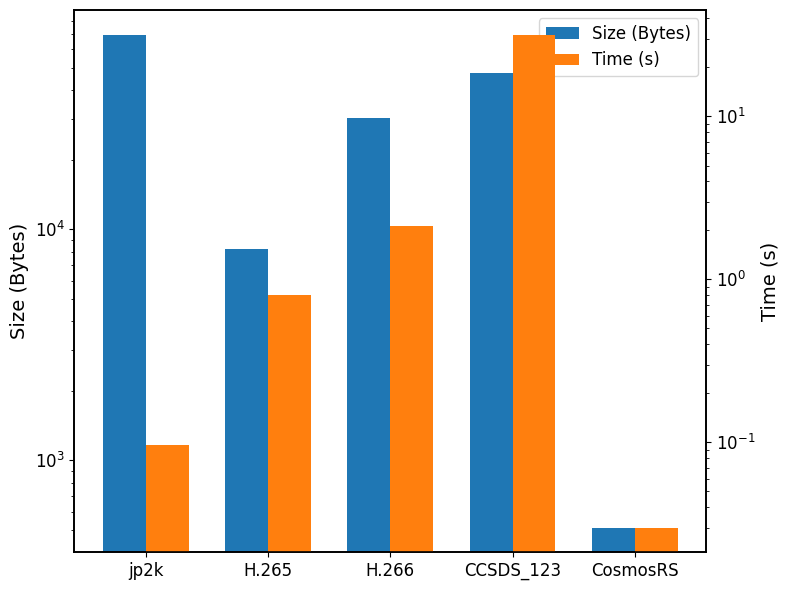

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(8, 6), dpi=100)

names = ["jp2k", "H.265", "H.266", "CCSDS_123", "CosmosRS"]
heights1_size = [69_533, 8_241, 30_251, 47_512, 512]
hights2_time = [0.0963, 0.8, 2.119, 31.76, 0.03]
x = np.arange(len(names))
width = 0.35

rects1 = ax1.bar(x - width / 2, heights1_size, width, label="Size (Bytes)", color="tab:blue")
ax1.set_ylabel("Size (Bytes)")
ax1.set_xticks(x)
ax1.set_xticklabels(names)
ax1.set_yscale("log")  # log scale for size

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width / 2, hights2_time, width, label="Time (s)", color="tab:orange")
ax2.set_ylabel("Time (s)")
ax2.set_yscale("log")  # log scale for time

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

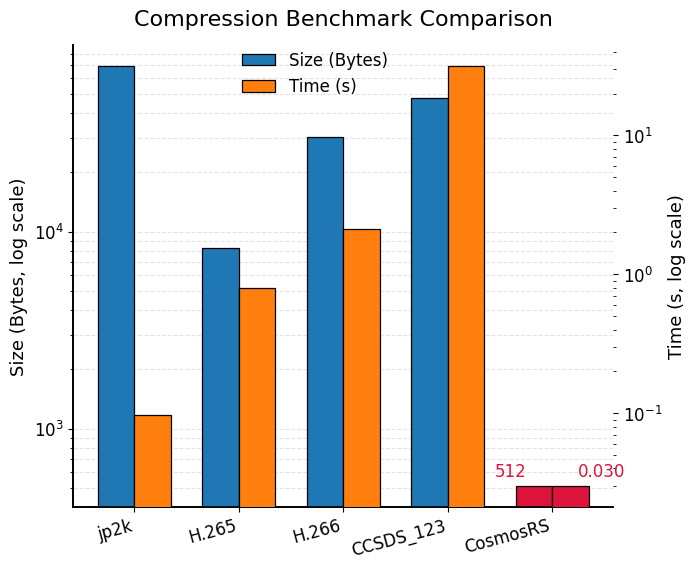

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.patches import Rectangle


def _annotate_bar(
    ax: Axes,
    rect: Rectangle,
    text: str,
    *,
    color: str,
    x_offset_points: float,
    y_offset_points: float = 4,
    fontsize: float = 12,
    ha: str = "center",
) -> None:
    x = rect.get_x() + rect.get_width() / 2
    y = rect.get_height()
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(x_offset_points, y_offset_points),
        textcoords="offset points",
        ha=ha,
        va="bottom",
        color=color,
        fontsize=fontsize,
        clip_on=False,
    )


def plot_compression_benchmark(
    names: list[str],
    sizes: list[int],
    times: list[float],
    highlight_idx: int = -1,
) -> None:
    """Draws a dual-axis bar chart for compression benchmark.

    Parameters
    ----------
    names : list[str]
        Algorithm names.
    sizes : list[int]
        Output sizes in bytes.
    times : list[float]
        Compression times in seconds.
    highlight_idx : int, optional
        Index to highlight (default: -1, no highlight).
    """
    style = {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial"],
        "axes.labelsize": 13,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.dpi": 100,
        "axes.linewidth": 1.2,
    }
    with plt.rc_context(style):
        fig, ax1 = plt.subplots(figsize=(8, 6), dpi=100)
        # Reserve space on the right for the legend (avoid covering the bars/labels).
        fig.subplots_adjust(right=0.80)

        x = np.arange(len(names))
        width = 0.35

        colors_size = ["tab:blue"] * len(names)
        colors_time = ["tab:orange"] * len(names)
        if highlight_idx >= 0:
            colors_size[highlight_idx] = "crimson"
            colors_time[highlight_idx] = "crimson"

        rects1 = ax1.bar(
            x - width / 2,
            sizes,
            width,
            label="Size (Bytes)",
            color=colors_size,
            edgecolor="black",
            linewidth=0.9,
            zorder=3,
        )
        ax1.set_ylabel("Size (Bytes, log scale)")
        ax1.set_yscale("log")
        ax1.set_xticks(x)
        ax1.set_xticklabels(names, rotation=15, ha="right")
        ax1.set_axisbelow(True)
        ax1.grid(True, which="both", axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

        ax2 = ax1.twinx()
        rects2 = ax2.bar(
            x + width / 2,
            times,
            width,
            label="Time (s)",
            color=colors_time,
            edgecolor="black",
            linewidth=0.9,
            zorder=3,
        )
        ax2.set_ylabel("Time (s, log scale)")
        ax2.set_yscale("log")
        ax2.grid(False)

        if highlight_idx >= 0:
            _annotate_bar(
                ax1,
                rects1[highlight_idx],
                f"{sizes[highlight_idx]:,}",
                color="crimson",
                x_offset_points=-5,
                ha="right",
            )
            _annotate_bar(
                ax2,
                rects2[highlight_idx],
                f"{times[highlight_idx]:.3f}",
                color="crimson",
                x_offset_points=5,
                ha="left",
            )

        ax1.spines["top"].set_visible(False)
        ax1.spines["right"].set_visible(False)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(
            handles1 + handles2,
            labels1 + labels2,
            loc="upper left",
            bbox_to_anchor=(0.3, 1.0),
            frameon=False,
            borderaxespad=0,
        )

        ax1.set_title("Compression Benchmark Comparison", pad=14)
        plt.show()


names = ["jp2k", "H.265", "H.266", "CCSDS_123", "CosmosRS"]
heights1_size = [69_533, 8_241, 30_251, 47_512, 512]
heights2_time = [0.0963, 0.8, 2.119, 31.76, 0.03]
plot_compression_benchmark(names, heights1_size, heights2_time, highlight_idx=4)